In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Dense, LSTM
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
data = pd.read_csv("spam_ham_dataset.csv")
X, y = data[["text"]], data["label_num"]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, 
                                                      test_size=0.2,
                                                      random_state=32)
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


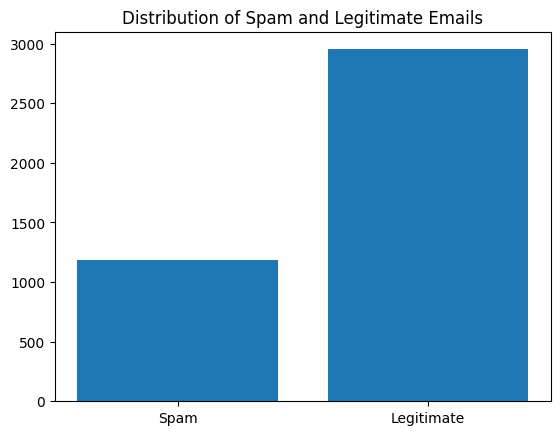

In [4]:
plt.bar(x=["Spam", "Legitimate"],
        height=[len(y_train[y_train==1]),
                len(y_train[y_train==0])]
)

plt.title("Distribution of Spam and Legitimate Emails")
plt.show()

In [5]:
ros = RandomOverSampler(random_state=0)
X_train, y_train = ros.fit_resample(X_train, y_train)

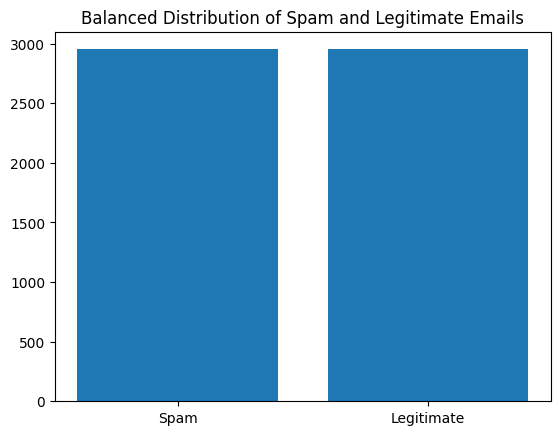

In [6]:
plt.bar(x=["Spam", "Legitimate"],
        height=[len(y_train[y_train==1]),
                len(y_train[y_train==0])]
)

plt.title("Balanced Distribution of Spam and Legitimate Emails")
plt.show()

In [7]:
class TextPreprocessor:
    def __init__(self):
        self.stop_words = stopwords.words('english')
        self.tokenizer = Tokenizer()
        self.max_len = 100

    def remove_punctuation(self, text: str):
        punctuation_remover = str.maketrans("", "", string.punctuation)
        return text.translate(punctuation_remover)

    def remove_stopwords(self, text: str):
        cleaned_words = [
            word.lower() for word in text.split() if word.lower() not in\
                self.stop_words
        ]
        return " ".join(cleaned_words)

    def remove_subject(self, text: str):
        return text[7:] if text[:7] == "Subject" else text
    
    def tokenize_padding(self, X):
        sequences = self.tokenizer.texts_to_sequences(X["text"])
        return pad_sequences(sequences,
                            maxlen=self.max_len,
                            padding='post',
                            truncating='post')

    def fit(self, X):
        self.tokenizer.fit_on_texts(X["text"])
    
    def transform(self, X):
        X_new = X.copy()
        
        steps = [
            self.remove_subject,
            self.remove_punctuation,
            self.remove_stopwords
        ]

        for func in steps:
            X_new["text"] = X_new["text"].apply(func)


        return self.tokenize_padding(X_new)


In [8]:
text_preprocessor = TextPreprocessor()
text_preprocessor.fit(X_train)

valid_sequences = text_preprocessor.transform(X_valid)
train_sequences = text_preprocessor.transform(X_train)

In [15]:
early_stopping = EarlyStopping(
    patience=5, monitor='val_accuracy', restore_best_weights=True
)
reduced_learning_rate = ReduceLROnPlateau(patience=5, monitor='val_loss')

model = keras.Sequential([
    Embedding(input_dim=len(text_preprocessor.tokenizer.word_index) + 1,
              output_dim=32),
    LSTM(16),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history_object = model.fit(
    train_sequences, y_train,
    validation_data=(valid_sequences, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=[reduced_learning_rate, early_stopping]
)

Epoch 1/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 42s 156ms/step - accuracy: 0.8098 - loss: 0.4162 - val_accuracy: 0.9507 - val_loss: 0.1898 - learning_rate: 0.0010
Epoch 2/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.9593 - loss: 0.1709 - val_accuracy: 0.9691 - val_loss: 0.1319 - learning_rate: 0.0010
Epoch 3/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.8493 - loss: 0.3485 - val_accuracy: 0.9430 - val_loss: 0.2729 - learning_rate: 0.0010
Epoch 4/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 73s 388ms/step - accuracy: 0.9685 - loss: 0.1466 - val_accuracy: 0.9749 - val_loss: 0.1091 - learning_rate: 0.0010
Epoch 5/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.9778 - loss: 0.1060 - val_accuracy: 0.9778 - val_loss: 0.0978 - learning_rate: 0.0010
Epoch 6/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.9824 - loss: 0.0877 - val_accuracy: 0.9807 - val_loss: 0.0890 - learning_rate: 0.0010
Epoch 7/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.9

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9836 - loss: 0.0796
Test Binary Cross-entropy:  0.07962530106306076
Test Accuracy:  0.9835748672485352


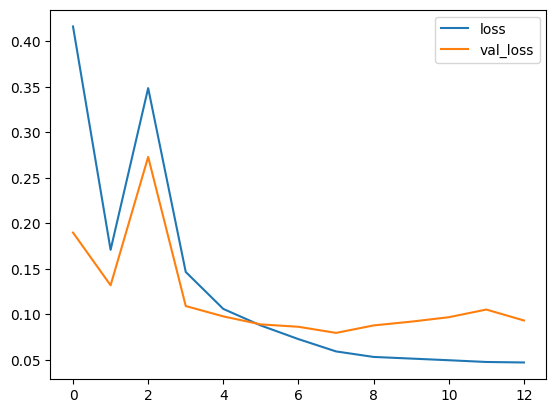

In [16]:
loss, accuracy = model.evaluate(valid_sequences, y_valid)
print("Test Binary Cross-entropy: ", loss)
print("Test Accuracy: ", accuracy)

history_data_frame = pd.DataFrame(history_object.history)
history_data_frame[["loss", "val_loss"]].plot()
plt.show()